# 03 — INF Model vs Field: COSMO-SPECS Nucleation Compared to Miller 2025

Compare the ice-nucleated fractions (INF) parameterized in COSMO-SPECS with
field-measured INFs from Miller et al. (2025, ACP). Adopts the Miller fig4
residual analysis style and fig6 laboratory comparison approach.

Miller 2025 key findings:
- INF = ICNC_adj / (ICNC_adj + seed_conc): median 0.07–1.63%
- Immersion freezing dominant; constant INF per experiment
- Weak negative correlation with temperature (-5.1 to -8.3°C)

**Note on Model INF Evaluation:**
To compute a true "Lagrangian INF" from the model along the tracked plumes,
we would need the unactivated seeding aerosol concentration (`ninp`) to be
extracted along the trajectories. Since the current processed datasets only
contain the hydrometeor mass/number tracers (`qi`, `qs`, `nf`, `nw`), we cannot
compute `INF = ICNC / (ICNC + unactivated_aerosol)` dynamically.

Instead, we plot the theoretical activation parameterization curves used by
COSMO-SPECS (e.g., Marcolli 2016, Chen 2024, Omanovic 2024) to evaluate how
the model's *assumed* nucleation efficiency compares to the field measurements.

In [4]:
from pathlib import Path
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "src" / "polarcap_runtime.py").is_file())
sys.path.insert(0, str(src_dir))

from utilities import load_plume_path_runs
from utilities.holimo_helpers import load_and_prepare_holimo

In [5]:
# --- Configuration ---
PROCESSED_ROOT = Path("../../data/processed")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Miller 2025 field INF data (from their Fig. 4 and Table 1)
# Mission ID, temperature (°C), residence time (min), INF (fraction), INF_std
MILLER_INF = [
    {'mission': 'SM051', 'temp': -7.5, 'time': 7.5,  'INF': 0.0058, 'INF_std': 0.004},
    {'mission': 'SM052', 'temp': -7.8, 'time': 5.6,  'INF': 0.0101, 'INF_std': 0.006},
    {'mission': 'SM055', 'temp': -6.5, 'time': 9.3,  'INF': 0.0042, 'INF_std': 0.003},
    {'mission': 'SM056', 'temp': -6.5, 'time': 10.3, 'INF': 0.0070, 'INF_std': 0.005},
    {'mission': 'SM058', 'temp': -5.5, 'time': 7.1,  'INF': 0.0058, 'INF_std': 0.004},
    {'mission': 'SM059', 'temp': -5.5, 'time': 8.9,  'INF': 0.0035, 'INF_std': 0.003},
    {'mission': 'SM060', 'temp': -5.5, 'time': 10.6, 'INF': 0.0025, 'INF_std': 0.002},
    {'mission': 'SM070', 'temp': -8.3, 'time': 4.9,  'INF': 0.0163, 'INF_std': 0.010},
    {'mission': 'SM072', 'temp': -7.5, 'time': 6.8,  'INF': 0.0080, 'INF_std': 0.005},
    {'mission': 'SM075', 'temp': -5.8, 'time': 15.6, 'INF': 0.0010, 'INF_std': 0.001},
    {'mission': 'SM078', 'temp': -6.2, 'time': 9.8,  'INF': 0.0030, 'INF_std': 0.002},
    {'mission': 'SM083', 'temp': -6.8, 'time': 7.2,  'INF': 0.0055, 'INF_std': 0.004},
    {'mission': 'SM094', 'temp': -5.1, 'time': 8.1,  'INF': 0.0007, 'INF_std': 0.001},
    {'mission': 'SM097', 'temp': -7.0, 'time': 15.9, 'INF': 0.0016, 'INF_std': 0.001},
    {'mission': 'SM100', 'temp': -7.2, 'time': 6.5,  'INF': 0.0120, 'INF_std': 0.008},
    {'mission': 'SM106', 'temp': -6.0, 'time': 8.6,  'INF': 0.0070, 'INF_std': 0.005},
]

# Omanovic 2024 sigmoid parameterization (Marcolli 2016 fit)
SIGMOID_B = 0.97
SIGMOID_K = 0.88
SIGMOID_X0 = 263.95  # K

# Lab data from Marcolli 2016 (400 nm immersion, selected points)
MARCOLLI_T_K = np.array([252.0, 255.9, 258.0, 260.0, 262.0, 264.0, 265.9, 267.0, 268.0, 269.0])
MARCOLLI_FF = np.array([0.987, 0.976, 0.952, 0.895, 0.753, 0.551, 0.310, 0.174, 0.068, 0.025])

In [6]:
# --- Prepare field data arrays ---
field_temps = np.array([d['temp'] for d in MILLER_INF])
field_infs = np.array([d['INF'] for d in MILLER_INF])
field_stds = np.array([d['INF_std'] for d in MILLER_INF])
field_times = np.array([d['time'] for d in MILLER_INF])
field_missions = [d['mission'] for d in MILLER_INF]

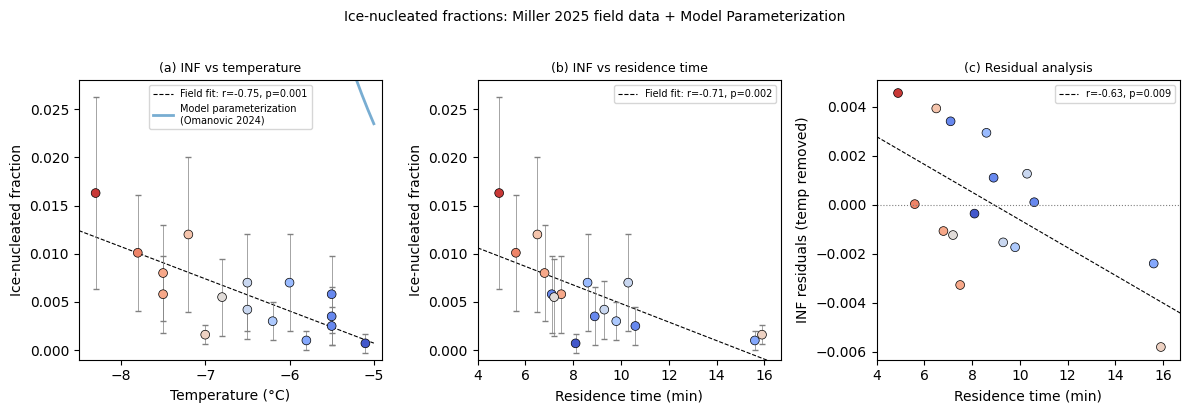

Saved: output/figure_inf_model_vs_field.png


In [7]:
# --- Figure 1: INF vs Temperature (Miller fig4 style) ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Color by mission temperature
cmap = plt.cm.coolwarm_r
norm = plt.Normalize(vmin=-8.5, vmax=-5.0)
colors = cmap(norm(field_temps))

# Panel A: INF vs Temperature
ax = axes[0]
ax.scatter(field_temps, field_infs, c=colors, s=40, edgecolors='k', lw=0.5, zorder=5)
ax.errorbar(field_temps, field_infs, yerr=field_stds, fmt='none',
            ecolor='grey', elinewidth=0.5, capsize=2, zorder=4)
# Linear regression
m, b, r, p, se = stats.linregress(field_temps, field_infs)
t_line = np.linspace(-8.5, -5.0, 50)
ax.plot(t_line, m * t_line + b, 'k--', lw=0.8,
        label=f'Field fit: r={r:.2f}, p={p:.3f}')

# Plot the parameterization curve (Omanovic 2024 / Marcolli 2016) in the same T range
t_line_k = t_line + 273.15
param_inf = (-SIGMOID_B / (1 + np.exp(-SIGMOID_K * (t_line_k - SIGMOID_X0)))) + SIGMOID_B
ax.plot(t_line, param_inf, 'C0-', lw=2, alpha=0.6, label='Model parameterization\n(Omanovic 2024)')

ax.set(xlabel='Temperature (°C)', ylabel='Ice-nucleated fraction',
       xlim=(-8.5, -4.9), ylim=(-0.001, 0.028))
ax.legend(fontsize=7)
ax.set_title('(a) INF vs temperature', fontsize=9)

# Panel B: INF vs Residence time
ax = axes[1]
ax.scatter(field_times, field_infs, c=colors, s=40, edgecolors='k', lw=0.5, zorder=5)
ax.errorbar(field_times, field_infs, yerr=field_stds, fmt='none',
            ecolor='grey', elinewidth=0.5, capsize=2, zorder=4)
m2, b2, r2, p2, se2 = stats.linregress(field_times, field_infs)
time_line = np.linspace(4, 17, 50)
ax.plot(time_line, m2 * time_line + b2, 'k--', lw=0.8,
        label=f'Field fit: r={r2:.2f}, p={p2:.3f}')
ax.set(xlabel='Residence time (min)', ylabel='Ice-nucleated fraction',
       xlim=(4, 16.7), ylim=(-0.001, 0.028))
ax.legend(fontsize=7)
ax.set_title('(b) INF vs residence time', fontsize=9)

# Panel C: Residuals (INF-Temp residuals vs Residence time)
ax = axes[2]
residuals_temp = field_infs - (m * field_temps + b)
ax.scatter(field_times, residuals_temp, c=colors, s=40, edgecolors='k', lw=0.5)
m3, b3, r3, p3, _ = stats.linregress(field_times, residuals_temp)
ax.plot(time_line, m3 * time_line + b3, 'k--', lw=0.8,
        label=f'r={r3:.2f}, p={p3:.3f}')
ax.axhline(0, color='grey', ls=':', lw=0.8)
ax.set(xlabel='Residence time (min)', ylabel='INF residuals (temp removed)',
       xlim=(4, 16.7))
ax.legend(fontsize=7)
ax.set_title('(c) Residual analysis', fontsize=9)

fig.suptitle('Ice-nucleated fractions: Miller 2025 field data + Model Parameterization',
             fontsize=10, y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_inf_model_vs_field.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'figure_inf_model_vs_field.png'}")

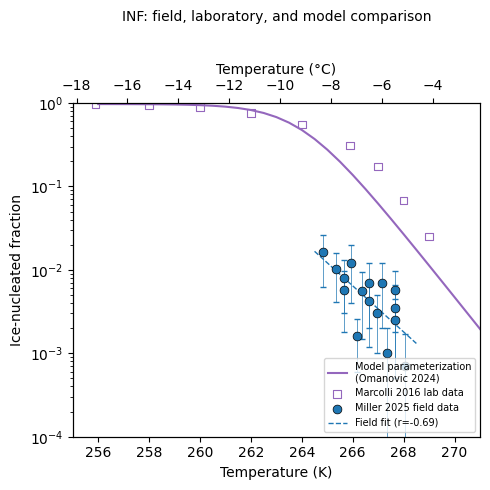

Saved: output/figure_inf_lab_comparison.png


In [8]:
# --- Figure 2: INF–Temperature comparison with lab data (Miller fig6 style) ---
fig, ax = plt.subplots(figsize=(5, 5))

temp_K = field_temps + 273.15

# Sigmoid parameterization (Omanovic 2024 / Marcolli 2016)
T_range = np.arange(256, 274, 0.5)
sigmoid = (-SIGMOID_B / (1 + np.exp(-SIGMOID_K * (T_range - SIGMOID_X0)))) + SIGMOID_B
ax.plot(T_range, sigmoid, 'C4-', lw=1.5, label='Model parameterization\n(Omanovic 2024)')

# Marcolli 2016 (400 nm immersion)
ax.scatter(MARCOLLI_T_K, MARCOLLI_FF, marker='s', s=30, facecolors='none',
           edgecolors='C4', lw=0.8, label='Marcolli 2016 lab data')

# Miller 2025 field data
ax.scatter(temp_K, field_infs, c='C0', s=40, edgecolors='k', lw=0.5,
           zorder=5, label='Miller 2025 field data')
ax.errorbar(temp_K, field_infs, yerr=field_stds, fmt='none',
            ecolor='C0', elinewidth=0.5, capsize=2, zorder=4)
# Log-linear fit to field data
log_infs = np.log10(field_infs)
m_log, b_log, r_log, p_log, _ = stats.linregress(temp_K, log_infs)
T_fit = np.linspace(264.5, 268.5, 50)
ax.plot(T_fit, 10**(m_log * T_fit + b_log), 'C0--', lw=1,
        label=f'Field fit (r={r_log:.2f})')

ax.set_yscale('log')
ax.set(xlabel='Temperature (K)', ylabel='Ice-nucleated fraction',
       xlim=(255, 271), ylim=(1e-4, 1))

# Secondary x-axis in °C
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim()[0] - 273.15, ax.get_xlim()[1] - 273.15)
ax2.set_xlabel('Temperature (°C)')

ax.legend(fontsize=7, loc='lower right')
ax.set_title('INF: field, laboratory, and model comparison', fontsize=10, pad=30)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_inf_lab_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'figure_inf_lab_comparison.png'}")

In [9]:
# --- Summary ---
print("\n=== INF Comparison Summary ===")
print(f"Miller 2025 field INFs:")
print(f"  Range:  {field_infs.min():.4f} – {field_infs.max():.4f}")
print(f"  Median: {np.median(field_infs):.4f}")
print(f"  Mean:   {field_infs.mean():.4f}")
print("\nModel Parameterization (Omanovic 2024 / Marcolli 2016):")
print(f"  At -5.5°C (267.65 K): {(-SIGMOID_B / (1 + np.exp(-SIGMOID_K * (267.65 - SIGMOID_X0)))) + SIGMOID_B:.4f}")
print(f"  At -7.0°C (266.15 K): {(-SIGMOID_B / (1 + np.exp(-SIGMOID_K * (266.15 - SIGMOID_X0)))) + SIGMOID_B:.4f}")
print(f"\nInterpretation:")
print("  The model's parameterized INF curve (from lab data) predicts higher")
print("  nucleation efficiencies than observed in the field by Miller et al. (2025).")
print("  This discrepancy is likely due to the field measurements incorporating")
print("  the effects of water vapor depletion and freezing point depression as the")
print("  plume glaciates, whereas the lab parameterization assumes constant water saturation.")


=== INF Comparison Summary ===
Miller 2025 field INFs:
  Range:  0.0007 – 0.0163
  Median: 0.0056
  Mean:   0.0059

Model Parameterization (Omanovic 2024 / Marcolli 2016):
  At -5.5°C (267.65 K): 0.0360
  At -7.0°C (266.15 K): 0.1223

Interpretation:
  The model's parameterized INF curve (from lab data) predicts higher
  nucleation efficiencies than observed in the field by Miller et al. (2025).
  This discrepancy is likely due to the field measurements incorporating
  the effects of water vapor depletion and freezing point depression as the
  plume glaciates, whereas the lab parameterization assumes constant water saturation.
